In [21]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 
e0 = 0.4
xI0 = 1.0
dist = 0.9  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = 10*loglike #NOTE: scaled 10x

    return log_likes

def prior_transform(u):

    logm1lim = [5.9, 6.2]
    logm2lim = [1.3,1.6]
    alim = [0.6, 0.8]
    p0lim= [10.0, 13.0]
    e0lim = [0.3, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 10.714024617672264
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [22]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_faceon_wider/sampler_state.pkl')

In [23]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [24]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.37149501, 0.82999498, 0.34983501, 0.59008503, 0.26174501],
        [0.37147941, 0.83000001, 0.34983811, 0.59008333, 0.26174259],
        [0.37150016, 0.82999373, 0.34984615, 0.59006939, 0.26174729],
        ...,
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ]],
       shape=(100000, 5)),
 array([[0.84839499, 0.779145  , 0.076175  , 0.149685  , 0.99528497],
        [0.84839488, 0.77914126, 0.0761844 , 0.14967793, 0.99529479],
        [0.84839452, 0.77916501, 0.07618383, 0.14968347, 0.99528861],
        ...,
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ]],
       shape=(100000, 5)),
 array([[0.58083498, 0.24786501, 0.028065  , 0.190485  , 0.92333502],
        

In [25]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([21.04746233, 21.02175067, 21.02588683, ...,  0.        ,
         0.        ,  0.        ], shape=(100000,)),
 array([14.4286483 , 14.42812756, 14.41611695, ...,  0.        ,
         0.        ,  0.        ], shape=(100000,)),
 array([14.6161119 , 14.5851279 , 14.61933191, ...,  0.        ,
         0.        ,  0.        ], shape=(100000,)),
 array([15.09687245, 15.11176766, 15.12078321, ...,  0.        ,
         0.        ,  0.        ], shape=(100000,))]

In [26]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))

maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
maxld_pt4 = prior_transform(proc_pt[3][np.argmax(logden_list)].reshape(1, -1))


In [27]:
maxld_pt1, maxld_pt2, maxld_pt3, maxld_pt4

(array([[ 5.9919396 ,  1.46955437,  0.68436329, 11.79626924,  0.40546647]]),
 array([[ 6.11536134,  1.58120197,  0.44167514, 11.57772703,  0.49714264]]),
 array([[6.12944065, 1.33809498, 0.76782457, 8.44862998, 0.49323371]]),
 array([[ 6.02759147,  1.51976065,  0.61969702, 12.37215935,  0.51049576]]))

In [28]:
h_pt1 = waveform_gen_comb(10**5.9919396,10**1.46955437,  0.68436329, 11.79626924,  0.40546647, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt,
    T=T
)



In [29]:
h_pt2 = waveform_gen_comb(10**6.11536134,  10**1.58120197,  0.44167514, 11.57772703,  0.49714264,xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt,
    T=T
)



In [30]:
gwf.rhostat(h_pt1)

array(10.84988677)

In [31]:
gwf.rhostat(h_pt2)

array(8.5131807)

In [32]:
h_pt3 = waveform_gen_comb(10**6.12944065, 10**1.33809498, 0.76782457, 8.44862998, 0.49323371, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt,
    T=T
)



In [33]:
h_pt4 = waveform_gen_comb(10**6.02759147,  10**1.51976065,  0.61969702, 12.37215935,  0.51049576, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt,
    T=T
)



In [34]:
gwf.rhostat(data), gwf.rhostat(h_pt1), gwf.rhostat(h_pt2), gwf.rhostat(h_pt3), gwf.rhostat(h_pt4)

(array(10.71402462),
 array(10.84988677),
 array(8.5131807),
 array(20.40472309),
 array(9.79958888))

In [37]:
gwf.Xstat(data, data), gwf.Xstat(data, h_pt1), gwf.Xstat(data, h_pt2), gwf.Xstat(data, h_pt3), gwf.Xstat(data, h_pt4)

(array(10.71402462),
 array(1.31803496),
 array(0.00697006),
 array(0.00838819),
 array(0.01928668))

In [38]:
gwf.overlap(gwf.freq_wave(data), gwf.freq_wave(h_pt1))

array(0.05562197)

In [41]:
gwf.overlap(gwf.freq_wave(data), gwf.freq_wave(h_pt2))

array(0.00049781)

In [ ]:
sampler.

In [35]:
param_true

[np.float64(6.0), np.float64(1.4771212547196624), 0.7, 11.7, 0.4]

In [36]:
param_ranges = [(5.9,6.2),
                (1.3,1.6),
                (0.6,0.8),
                (10.0,13.0),
                (0.3,0.5)
                ]
param_ranges

[(5.9, 6.2), (1.3, 1.6), (0.6, 0.8), (10.0, 13.0), (0.3, 0.5)]

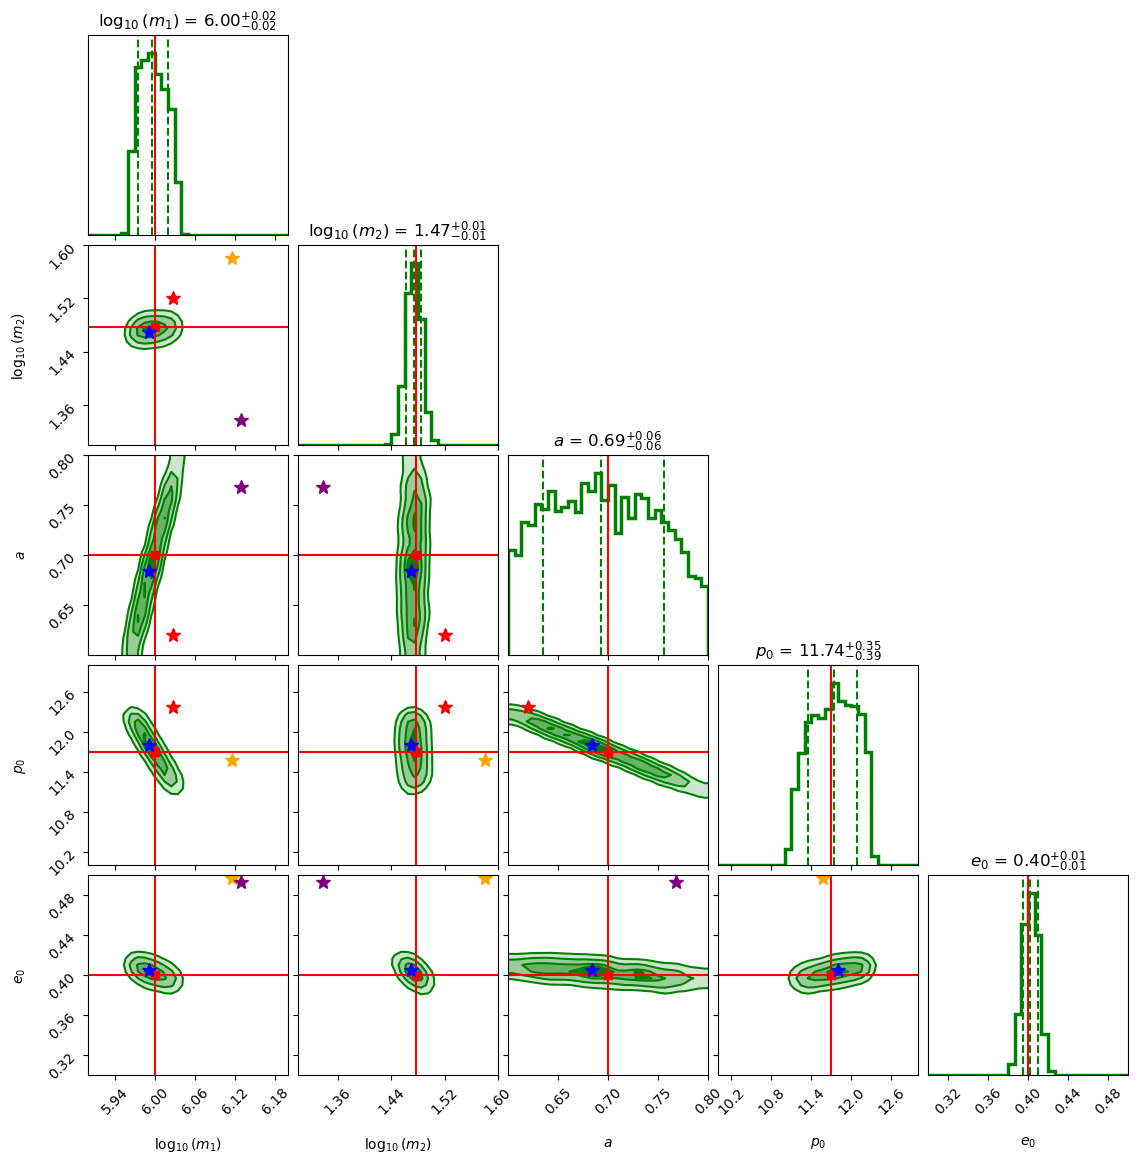

In [54]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)
corner.overplot_points(fig, maxld_pt2.reshape(1, -1), 
                       color='orange', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt3.reshape(1, -1), 
                       color='purple', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt4.reshape(1, -1), 
                       color='red', marker='*', ms=10, 
                       reverse=False)
# corner.overplot_points(fig, proc2_maxld_pt.reshape(1, -1), 
#                        color='orange', marker='*', ms=10,
#                        reverse=False)

